# Housing Price Category Prediction

## Task 1: Dataset Preparation

This project uses a personalized Housing dataset to predict
Price Category (Affordable / Expensive) using a Decision Tree Classifier.

### Dataset Features
- House_ID
- Area (sq. ft.)
- Bedrooms
- Age
- Price Category

### Dataset Personalization
Last two digits of enrollment number: 25

In [1]:
import pandas as pd

# Load the housing dataset
df = pd.read_csv(r"D:\Housing-Decision-Tree\data\housing.csv")

# Display first five records
df.head()

,House_ID,Area,Bedrooms,Age,Price_Category
0,H251,850,2,18,Affordable
1,H252,950,2,15,Affordable
2,H253,1100,2,12,Affordable
3,H254,1200,3,14,Affordable
4,H255,1250,3,10,Affordable


## Task 2: Data Exploration

In [2]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   House_ID        20 non-null     str  
 1   Area            20 non-null     int64
 2   Bedrooms        20 non-null     int64
 3   Age             20 non-null     int64
 4   Price_Category  20 non-null     str  
dtypes: int64(3), str(2)
memory usage: 932.0 bytes


In [3]:
# Check for missing values
df.isnull().sum()

House_ID          0
Area              0
Bedrooms          0
Age               0
Price_Category    0
dtype: int64

In [4]:
# Display summary statistics
df.describe()

,Area,Bedrooms,Age
count,20.000000,20.000000,20.000000
mean,1490.000000,3.100000,10.200000
std,353.404495,0.718185,4.583724
min,850.000000,2.000000,4.000000
25%,1237.500000,3.000000,6.750000
50%,1475.000000,3.000000,9.500000
75%,1762.500000,4.000000,13.250000
max,2100.000000,4.000000,20.000000


In [5]:
# Count houses in each price category
df["Price_Category"].value_counts()

Price_Category
Affordable    10
Expensive     10
Name: count, dtype: int64

### Task 2 Observation

- The dataset contains 20 housing records.
- There are 5 columns in the dataset.
- No missing values are present.
- The dataset contains both Affordable and Expensive houses.
- There are 10 Affordable houses and 10 Expensive houses.

## Day 3 – Train/Test Split

In [6]:
X = df[["Area", "Bedrooms", "Age"]]
y = df["Price_Category"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Area  Bedrooms  Age
0   850         2   18
1   950         2   15
2  1100         2   12
3  1200         3   14
4  1250         3   10

Target (y):
0    Affordable
1    Affordable
2    Affordable
3    Affordable
4    Affordable
Name: Price_Category, dtype: str


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=25
)

In [9]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (16, 3)
Testing data: (4, 3)
Training target: (16,)
Testing target: (4,)


## Day 4 – Decision Tree Model Training

In [10]:
# Import Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Create model
model = DecisionTreeClassifier(random_state=25)

# Train model
model.fit(X_train, y_train)

# Confirmation
print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [11]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",25
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

## Day 5 – House Price Category Prediction

In [12]:
y_pred = model.predict(X_test)

print("Actual Price Categories:")
print(y_test.tolist())

print("\nPredicted Price Categories:")
print(y_pred.tolist())

Actual Price Categories:
['Expensive', 'Expensive', 'Affordable', 'Expensive']

Predicted Price Categories:
['Expensive', 'Expensive', 'Affordable', 'Expensive']


In [13]:
import pandas as pd

new_house = pd.DataFrame({
    "Area": [1700],
    "Bedrooms": [3],
    "Age": [6]
})

prediction = model.predict(new_house)

print("New House Details:")
print(new_house)

print("\nPredicted Price Category:", prediction[0])

New House Details:
   Area  Bedrooms  Age
0  1700         3    6

Predicted Price Category: Expensive


## Day 6 – Model Performance Evaluation

In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 100.0 %


In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Affordable", "Expensive"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1 0]
 [0 3]]


In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    labels=["Affordable", "Expensive"],
    zero_division=0
))

              precision    recall  f1-score   support

  Affordable       1.00      1.00      1.00         1
   Expensive       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



## Day 7 – Decision Tree Visualization

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

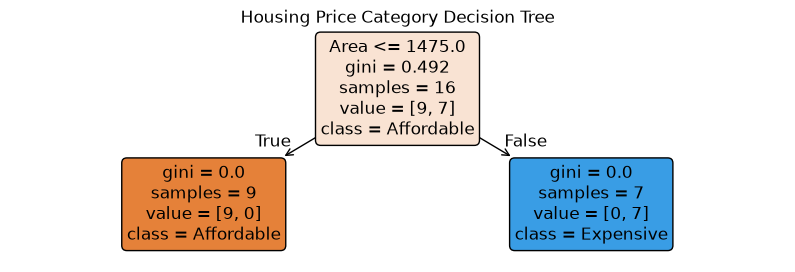

In [26]:
plt.figure(figsize=(10, 3))

plot_tree(
    model,
    feature_names=["Area", "Bedrooms", "Age"],
    class_names=model.classes_,
    filled=True,
    rounded=True
)

plt.title("Housing Price Category Decision Tree")
plt.savefig("decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()